In [81]:
from Objects.WSBM import *
from Objects.TWSBMInstance import *
from scipy.linalg import svd

def spectral_embedding(A, mode, d=2):
	vals, vecs = eigsh(A.astype(np.float32), k=d, which='LM')

	j = np.argmax(np.abs(vecs), axis=0)
	signs = np.sign(vecs[j, np.arange(vecs.shape[1])])
	vecs *= signs[None, :]

	if mode == 'sqrt-scaled':
		return vecs * np.sqrt(np.abs(vals)), vals
	elif mode == 'scaled':
		return vecs * np.abs(vals), vals
	elif mode == 'raw':
		return vecs, vals
	else:
		raise ValueError(f"Unknown embedding mode: {mode}")
	
def Σ_true(B, Z, C, Π):
	K = B.shape[0]
	H = np.eye(K)[Z]
	X_B, Λ_B = spectral_embedding(B, 'sqrt-scaled')
	X = H @ X_B
	print(Λ_B.shape)
	I_pq = np.sign(np.diag(Λ_B))
	Δ = X.T @ X
	Δ_inv = np.linalg.inv(Δ)

	M = np.tensordot(C * Π[np.newaxis, :], 
				  X_B[:, :, None] * X_B[:, None, :], axes=([1], [0]))

	return (I_pq @ Δ_inv)[None, :, :] @ M @ (Δ_inv @ I_pq)[None, :, :]

def procrustes_align(A, A_ref):
	M = A.T @ A_ref
	U, Σ, Vt = svd(M)
	R = U @ Vt
	return A @ R

In [82]:
#m = betaWSBM(0.1, 0.5, (0.9, 0.5), n = 1000)
m = betaWSBM(0.1, 0.5, (0.1, 0.1), n = 1000)
#t = PowerTransform(1.41)
t = OppositeTransform()
A, Z = m(seed=42)
G = TWSBMInstance(model = m, transformation = t, A = t(A), Z = Z)

B, C = G.model.theoretical_B_C(G.transformation)
X_B, _ = spectral_embedding(B, mode='sqrt-scaled')
X_B_hat = np.stack([G.X[G.Z == z].mean(axis=0) for z in np.unique(G.Z)])
X_B = procrustes_align(X_B, X_B_hat)
Σ = Σ_true(B, G.Z, C, G.model.Π)

(2,)


C:\Users\Nicol\AppData\Local\Temp\ipykernel_15624\2488337899.py:6: RuntimeWarning: k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.
  vals, vecs = eigsh(A.astype(np.float32), k=d, which='LM')


In [85]:
print(Σ*1000)
print(G.Σ)

[[[[ 0.00265749  0.00123798]
   [ 0.00123798  0.00057671]]

  [[ 0.00167451 -0.00049924]
   [-0.00049924  0.00014884]]]]
[[[ 0.00976924  0.00055167]
  [ 0.00055167  0.00098032]]

 [[ 0.00598999 -0.00086123]
  [-0.00086123  0.00075553]]]


In [126]:
from matplotlib.colors import to_rgb

for name, color in CMAP.items():
    rgb_float = to_rgb(color)
    rgb_255 = tuple(int(255 * c) for c in rgb_float)
    name = name if isinstance(name, str) else name.id
    print(f"{name}: {rgb_255}")

C_true: (255, 215, 0)
gC_true: (255, 215, 0)
C_graph: (0, 128, 128)
gC_graph: (0, 128, 128)
C_embed: (255, 0, 255)
gC_embed: (255, 0, 255)
P-0.50: (0, 255, 255)
P-0.71: (0, 230, 255)
P-1.00: (0, 196, 255)
P-1.41: (0, 148, 255)
P-2.00: (0, 80, 255)
Q-01: (255, 178, 198)
Q-05: (255, 164, 182)
Q-10: (255, 145, 161)
Q-25: (255, 90, 100)
Q-50: (255, 0, 0)
Opp: (255, 165, 0)
Log: (0, 128, 0)
Rank: (128, 0, 128)


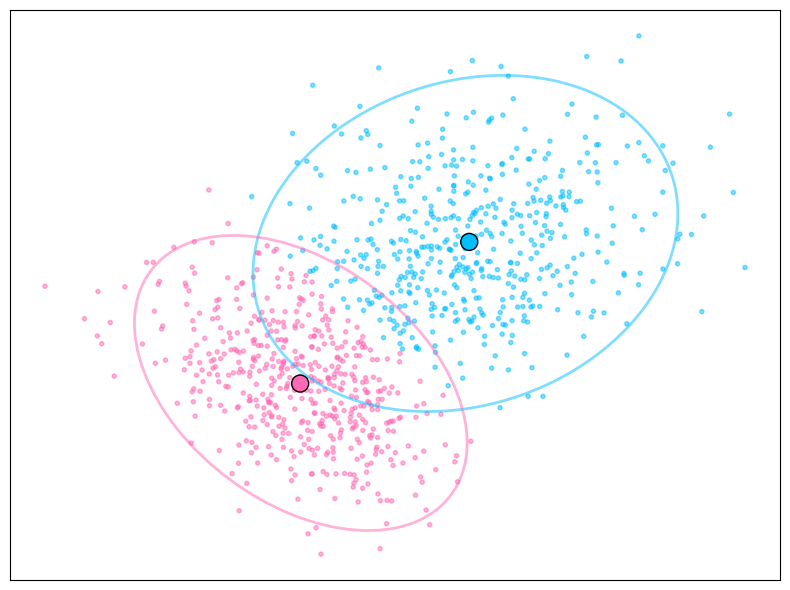

In [123]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.figure(figsize=(8, 6))

c_true = G.Z
cmap_true = "bwr"
c_pred = G.Z_hat
cmap_pred = ListedColormap(["deepskyblue", "hotpink"])

#plt.scatter(G.X[:, 0], G.X[:, 1], c='black', marker='.', alpha=1)
#plt.scatter(G.X[:, 0], G.X[:, 1], c=c_true, cmap=cmap_true, marker='.', alpha=0.5)
plt.scatter(G.X[:, 0], G.X[:, 1], c=c_pred, cmap=cmap_pred, marker='.', alpha=0.5)
#plt.scatter(X_B[:, 0], X_B[:, 1], c=[0, 1], cmap=cmap_true, marker='o', alpha=1, s=150, linewidth=1, edgecolor='black')
plt.scatter(X_B_hat[:, 0], X_B_hat[:, 1], c=[0, 1], cmap=cmap_pred, marker='o', alpha=1, s=150, linewidth=1, edgecolor='black')
ax = plt.gca()

for c, mean, cov in zip(["deepskyblue", "hotpink"], G.M, G.Σ):
	eigenvalues, eigenvectors = np.linalg.eigh(cov)
	angle = np.degrees(np.arctan2(eigenvectors[0, 1], eigenvectors[0, 0]))
	width, height = 2 * np.sqrt(6 * eigenvalues)
	ellipse = plt.matplotlib.patches.Ellipse(
		xy=mean, width=width, height=height, angle=angle,
		edgecolor=c, facecolor='none', linestyle='solid', linewidth=2, alpha=0.5)
	plt.gca().add_patch(ellipse)

x_ticks = np.linspace(*ax.get_xlim(), num=6)
y_ticks = np.linspace(*ax.get_ylim(), num=6)
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])
#ax.legend(loc='upper right', fontsize=12)

plt.grid(True)
plt.tight_layout()
#plt.axis('off')
plt.show()

In [297]:
m = betaWSBM(0.25, 0.1, (0.1, 1))
t1 = IdentityTransform()
t2 = ThresholdTransform(0.1)
A, Z = m(seed=42)
G1 = TWSBMInstance(model = m, transformation = t1, A = t1(A), Z = Z)
G2 = TWSBMInstance(model = m, transformation = t2, A = t2(A), Z = Z)

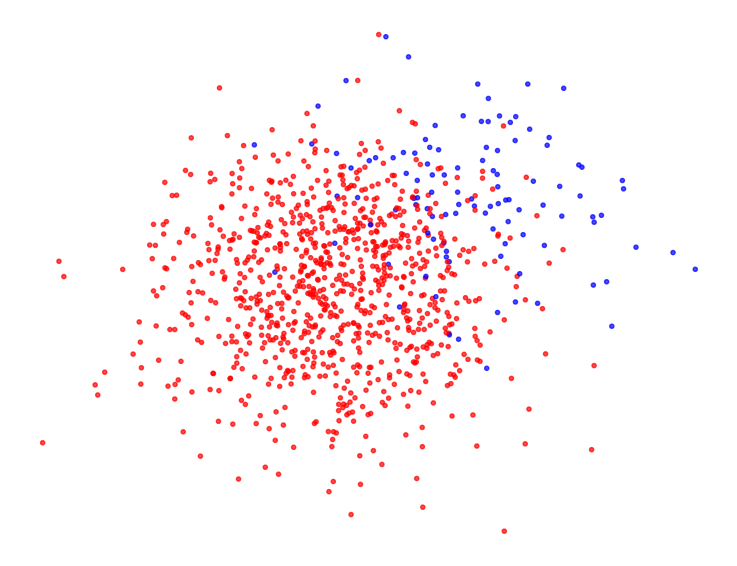

In [308]:
plt.figure(figsize=(8, 6))

plt.scatter(G1.X[:, 0], G1.X[:, 1], c=G1.Z, cmap='bwr', marker='.', alpha=0.7)
ax = plt.gca()

plt.tight_layout()
plt.axis('off')
plt.show()

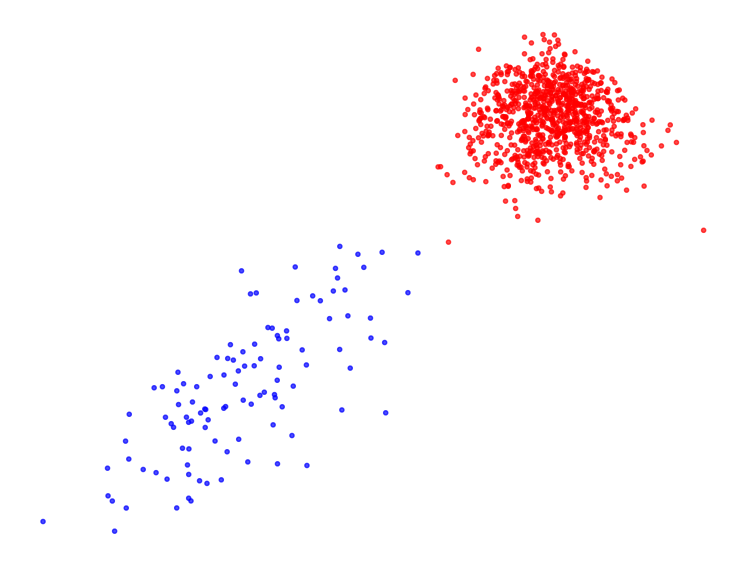

In [309]:
plt.figure(figsize=(8, 6))

plt.scatter(G2.X[:, 0], G2.X[:, 1], c=G2.Z, cmap='bwr', marker='.', alpha=0.7)
ax = plt.gca()

plt.tight_layout()
plt.axis('off')
plt.show()

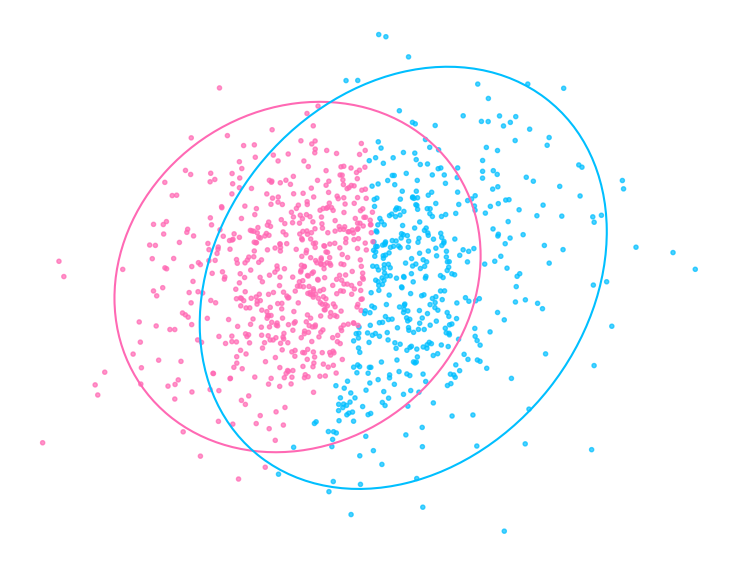

In [ ]:
from matplotlib.colors import ListedColormap

plt.figure(figsize=(8, 6))

cmap = ListedColormap(["hotpink", "deepskyblue"])
plt.scatter(G1.X[:, 0], G1.X[:, 1], c=G1.Z_hat, cmap=cmap, marker='.', alpha=0.7)
ax = plt.gca()

for c, mean, cov in zip(["hotpink", "deepskyblue"], G1.M, G1.Σ):
	eigenvalues, eigenvectors = np.linalg.eigh(cov)
	angle = np.degrees(np.arctan2(eigenvectors[0, 1], eigenvectors[0, 0]))
	width, height = 2 * np.sqrt(6 * eigenvalues)
	ellipse = plt.matplotlib.patches.Ellipse(
		xy=mean, width=width, height=height, angle=angle,
		edgecolor=c, facecolor='none', linestyle='solid', linewidth=1.5, alpha=1)
	plt.gca().add_patch(ellipse)


plt.tight_layout()
plt.axis('off')
plt.show()

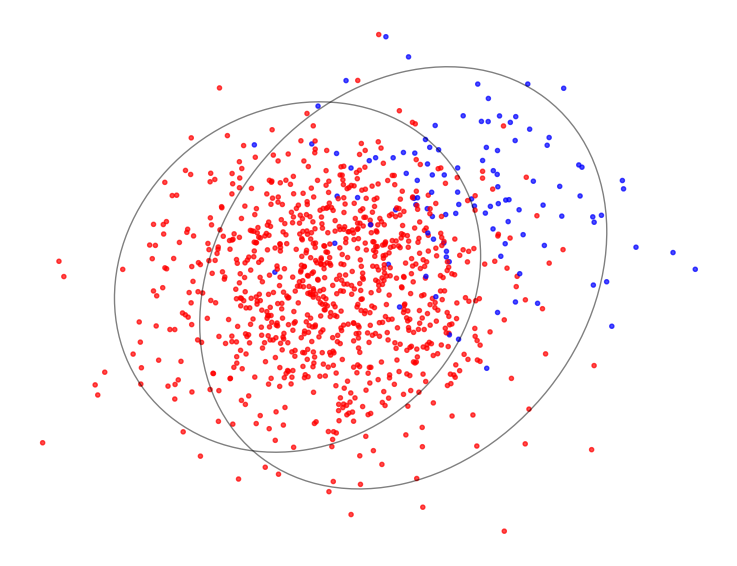

In [ ]:
from matplotlib.colors import ListedColormap

plt.figure(figsize=(8, 6))

cmap = ListedColormap(["deepskyblue", "hotpink"])
plt.scatter(G1.X[:, 0], G1.X[:, 1], c=G1.Z, cmap='bwr', marker='.', alpha=0.7)
ax = plt.gca()

for c, mean, cov in zip(["deepskyblue", "hotpink"], G1.M, G1.Σ):
	eigenvalues, eigenvectors = np.linalg.eigh(cov)
	angle = np.degrees(np.arctan2(eigenvectors[0, 1], eigenvectors[0, 0]))
	width, height = 2 * np.sqrt(6 * eigenvalues)
	ellipse = plt.matplotlib.patches.Ellipse(
		xy=mean, width=width, height=height, angle=angle,
		edgecolor='black', facecolor='none', linestyle='solid', linewidth=1, alpha=0.5)
	plt.gca().add_patch(ellipse)


plt.tight_layout()
plt.axis('off')
plt.show()

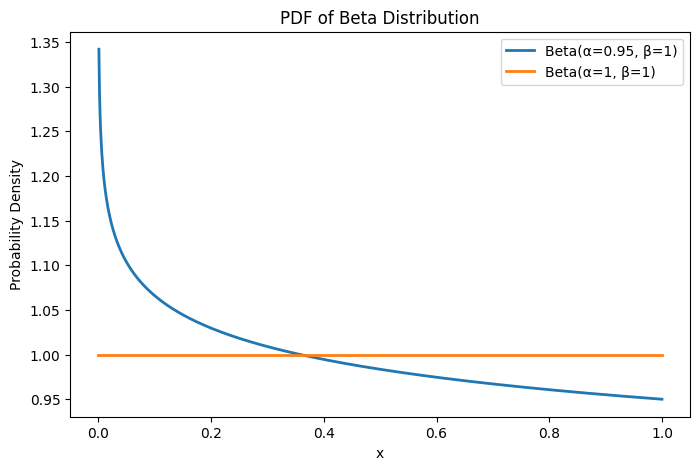

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta


x = np.linspace(0, 1, 1000)

# Calculate the pdf for each x value
a1 = 0.95
a2 = 1
b = 1

plt.figure(figsize=(8, 5))
plt.plot(x, beta.pdf(x, a1, 1), label=f'Beta(α={a1}, β={b})', lw=2)
plt.plot(x, beta.pdf(x, a2, 1), label=f'Beta(α={a2}, β={b})', lw=2)
plt.title('PDF of Beta Distribution')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

In [134]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

colors = {0: "blue", 1: "red", 2 : "purple"}

G = nx.from_numpy_array(A)
G0 = [n for n in G.nodes() if Z[n] == 0]
G1 = [n for n in G.nodes() if Z[n] == 1]
E0 = [e for e in G.edges() if Z[e[0]] == 0 and Z[e[1]] == 0]
E1 = [e for e in G.edges() if Z[e[0]] == 1 and Z[e[1]] == 1]
E01 = [e for e in G.edges() if Z[e[0]] != Z[e[1]]]
W0 = np.array([G[u][v]['weight'] for u, v in E0])
W1 = np.array([G[u][v]['weight'] for u, v in E1])
W01 = np.array([G[u][v]['weight'] for u, v in E01])


superG = nx.cycle_graph(2)
superpos = nx.spring_layout(superG, scale=0.4, seed=42)

pos = {}
seed_val = 1430
pos.update(nx.spring_layout(G.subgraph(G0), center=superpos[0], seed=seed_val, scale=1))
pos.update(nx.spring_layout(G.subgraph(G1), center=superpos[1], seed=seed_val, scale=0.6))

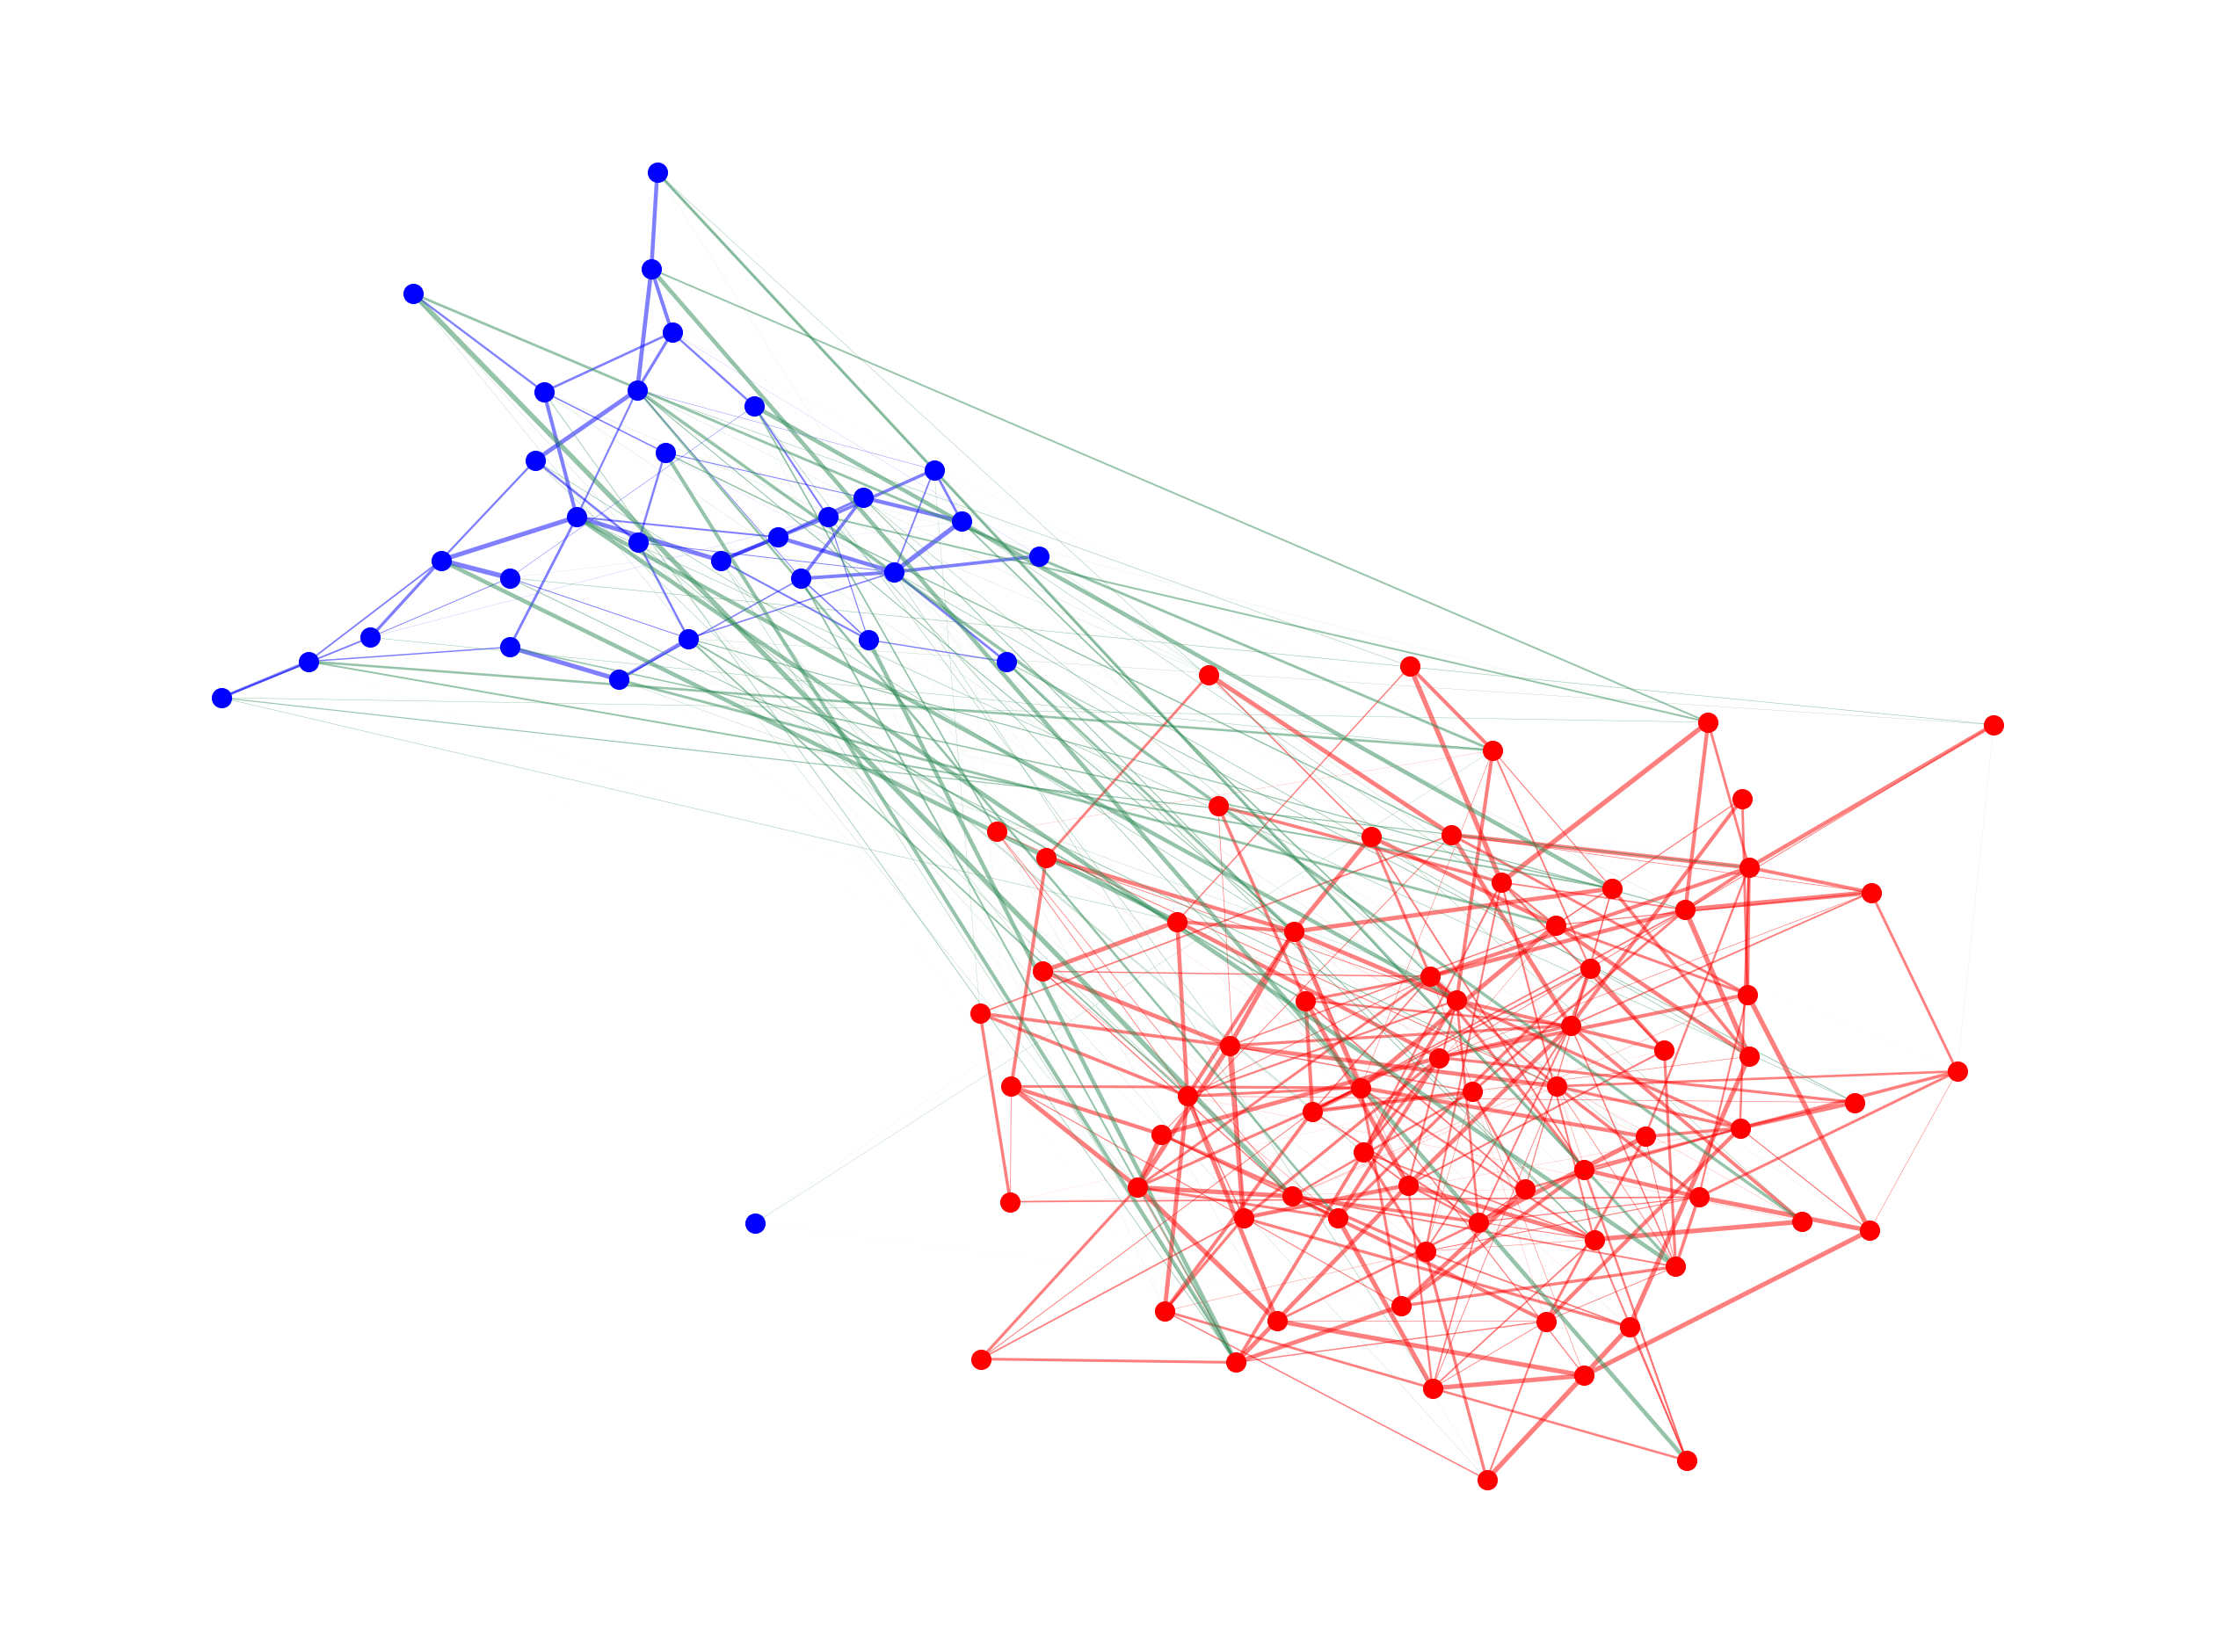

In [143]:
nx.draw_networkx_nodes(G, pos, nodelist=G0, node_color=colors[0], node_size=10, alpha=1)
nx.draw_networkx_nodes(G, pos, nodelist=G1, node_color=colors[1], node_size=10, alpha=1)
nx.draw_networkx_edges(G, pos, edgelist=E0, width=W0, edge_color=colors[0], alpha=0.5)
nx.draw_networkx_edges(G, pos, edgelist=E1, width=W1, edge_color=colors[1], alpha=0.5)
nx.draw_networkx_edges(G, pos, edgelist=E01, width=W01, edge_color="seagreen", alpha=0.5)

plt.tight_layout()
plt.axis('off')
plt.gcf().set_dpi(400)
plt.show()

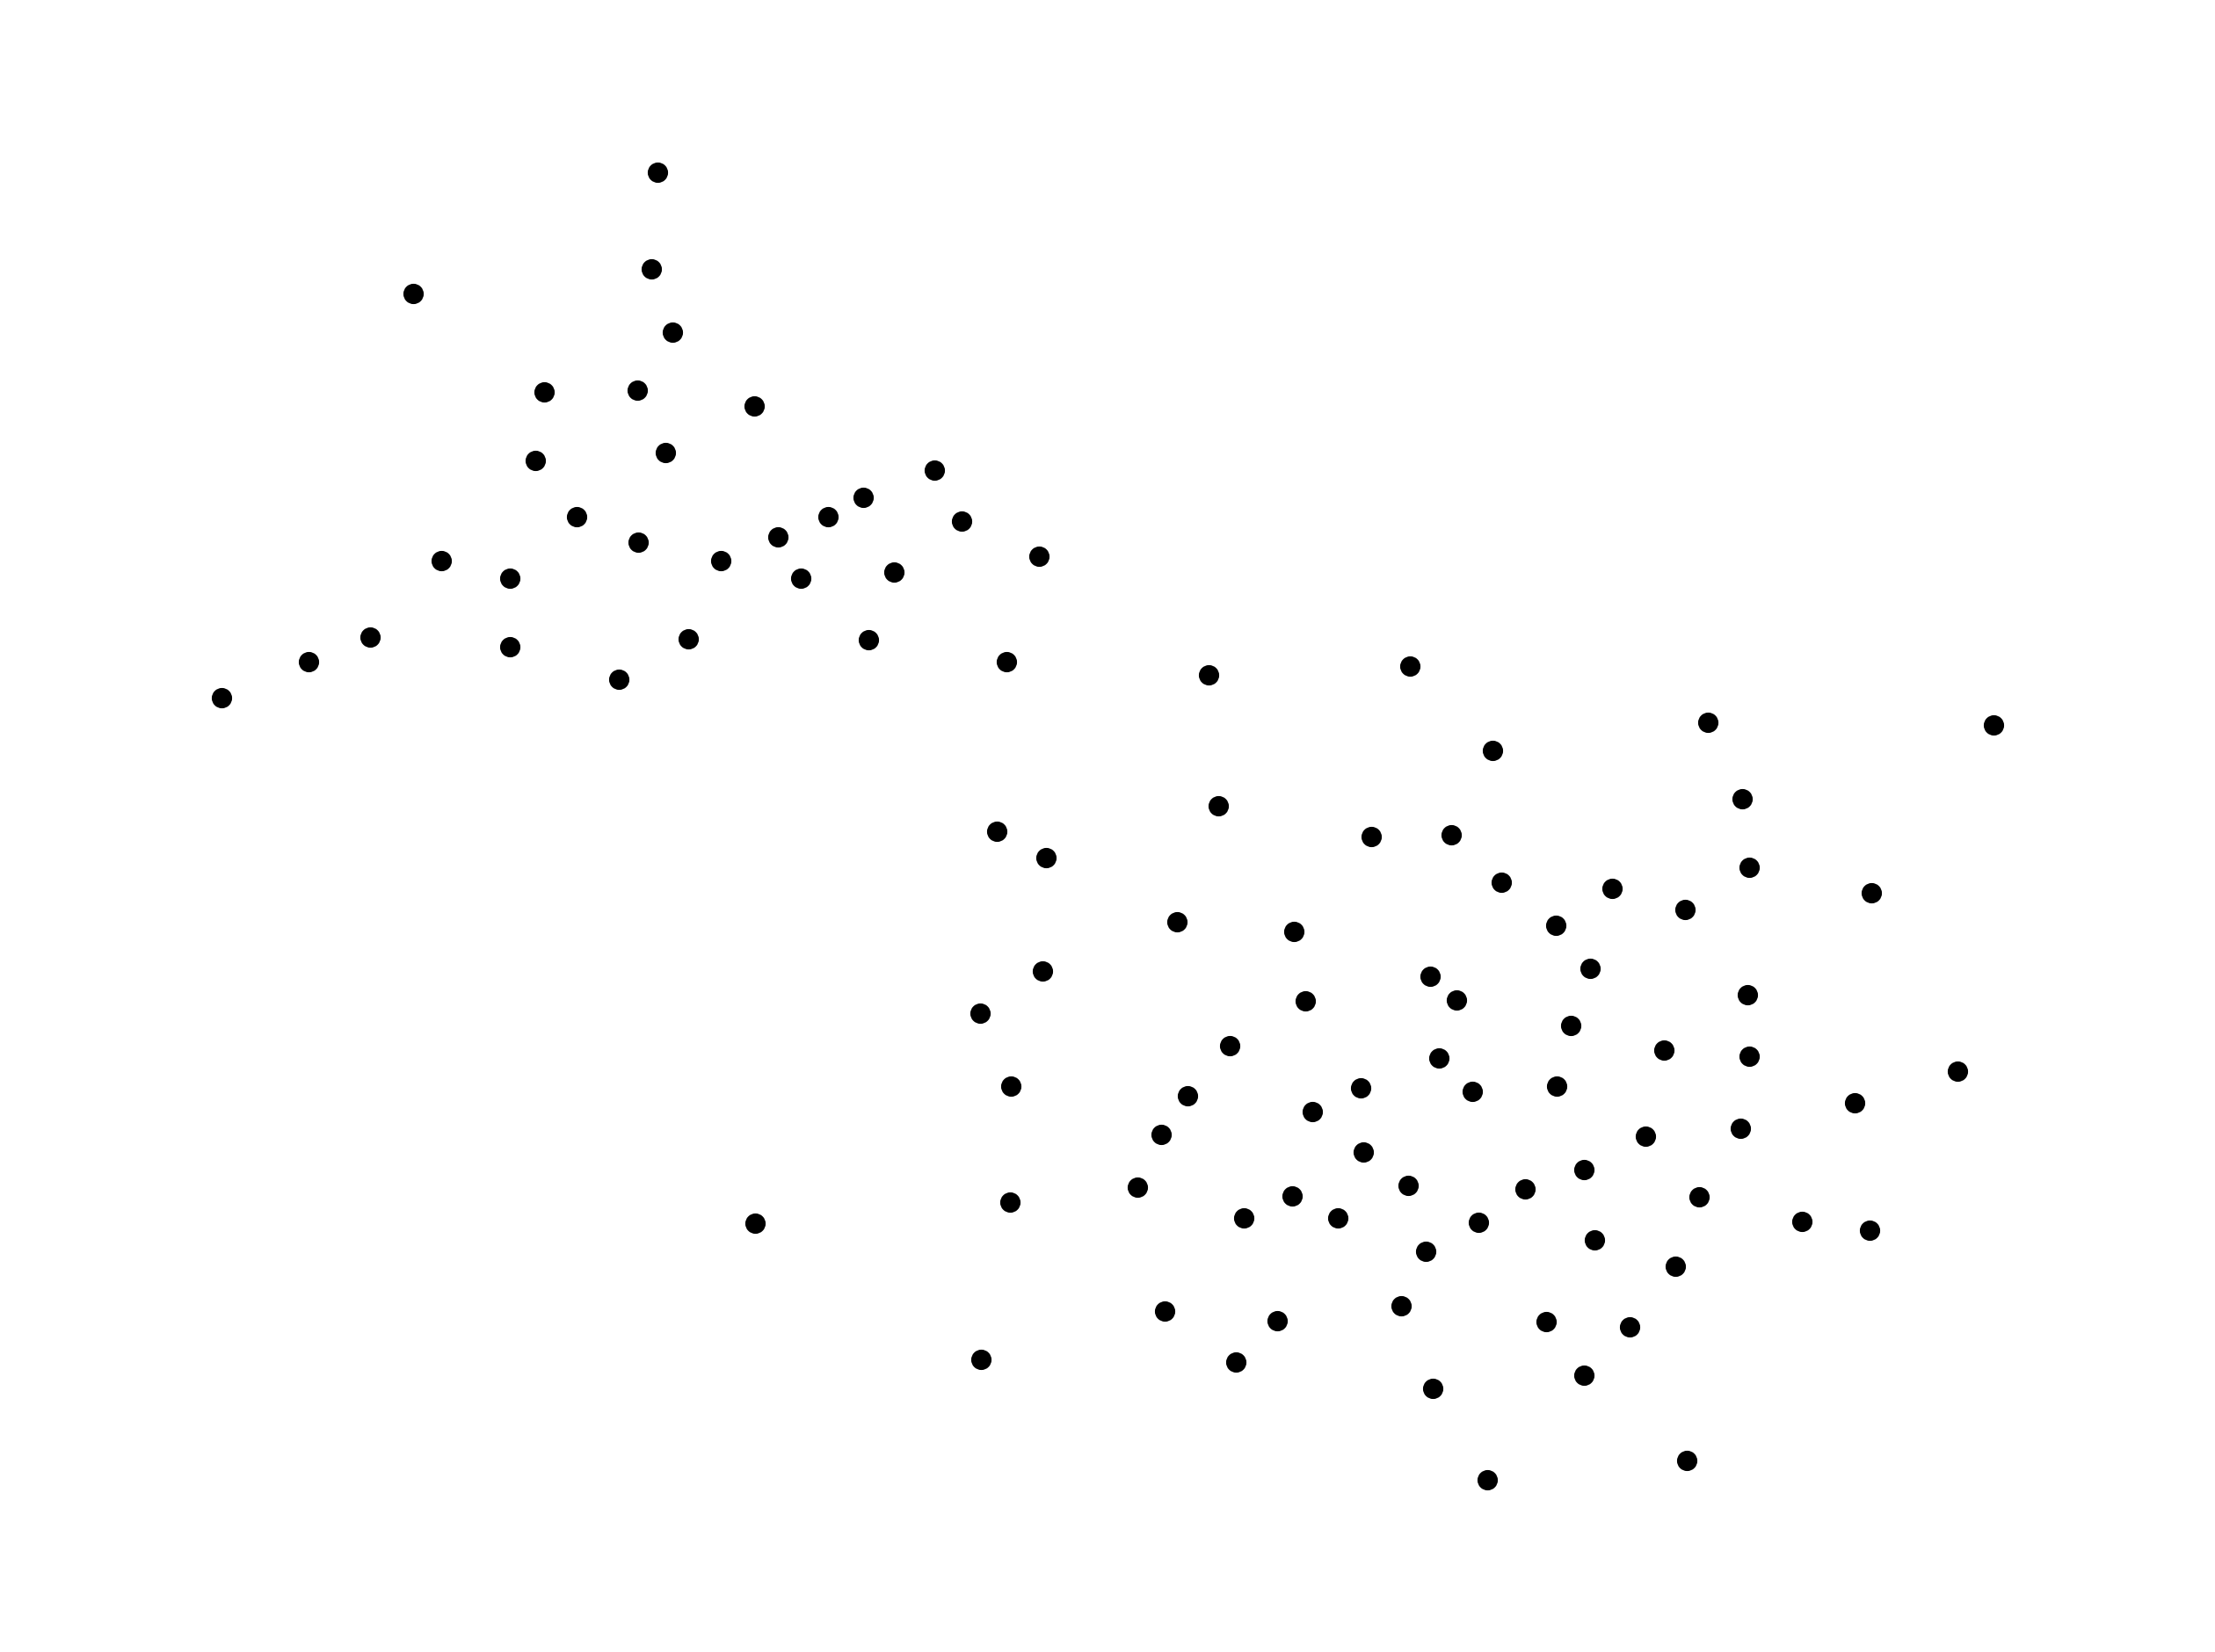

In [168]:
nx.draw_networkx_nodes(G, pos, nodelist=G0, node_color="black", node_size=10, alpha=1)
nx.draw_networkx_nodes(G, pos, nodelist=G1, node_color="black", node_size=10, alpha=1)
nx.draw_networkx_edges(G, pos, edgelist=E0, width=W0, edge_color=colors[0], alpha=0)
nx.draw_networkx_edges(G, pos, edgelist=E1, width=W1, edge_color=colors[1], alpha=0)
nx.draw_networkx_edges(G, pos, edgelist=E01, width=W01, edge_color="seagreen", alpha=0)

plt.tight_layout()
plt.axis('off')
plt.gcf().set_dpi(400)
plt.show()

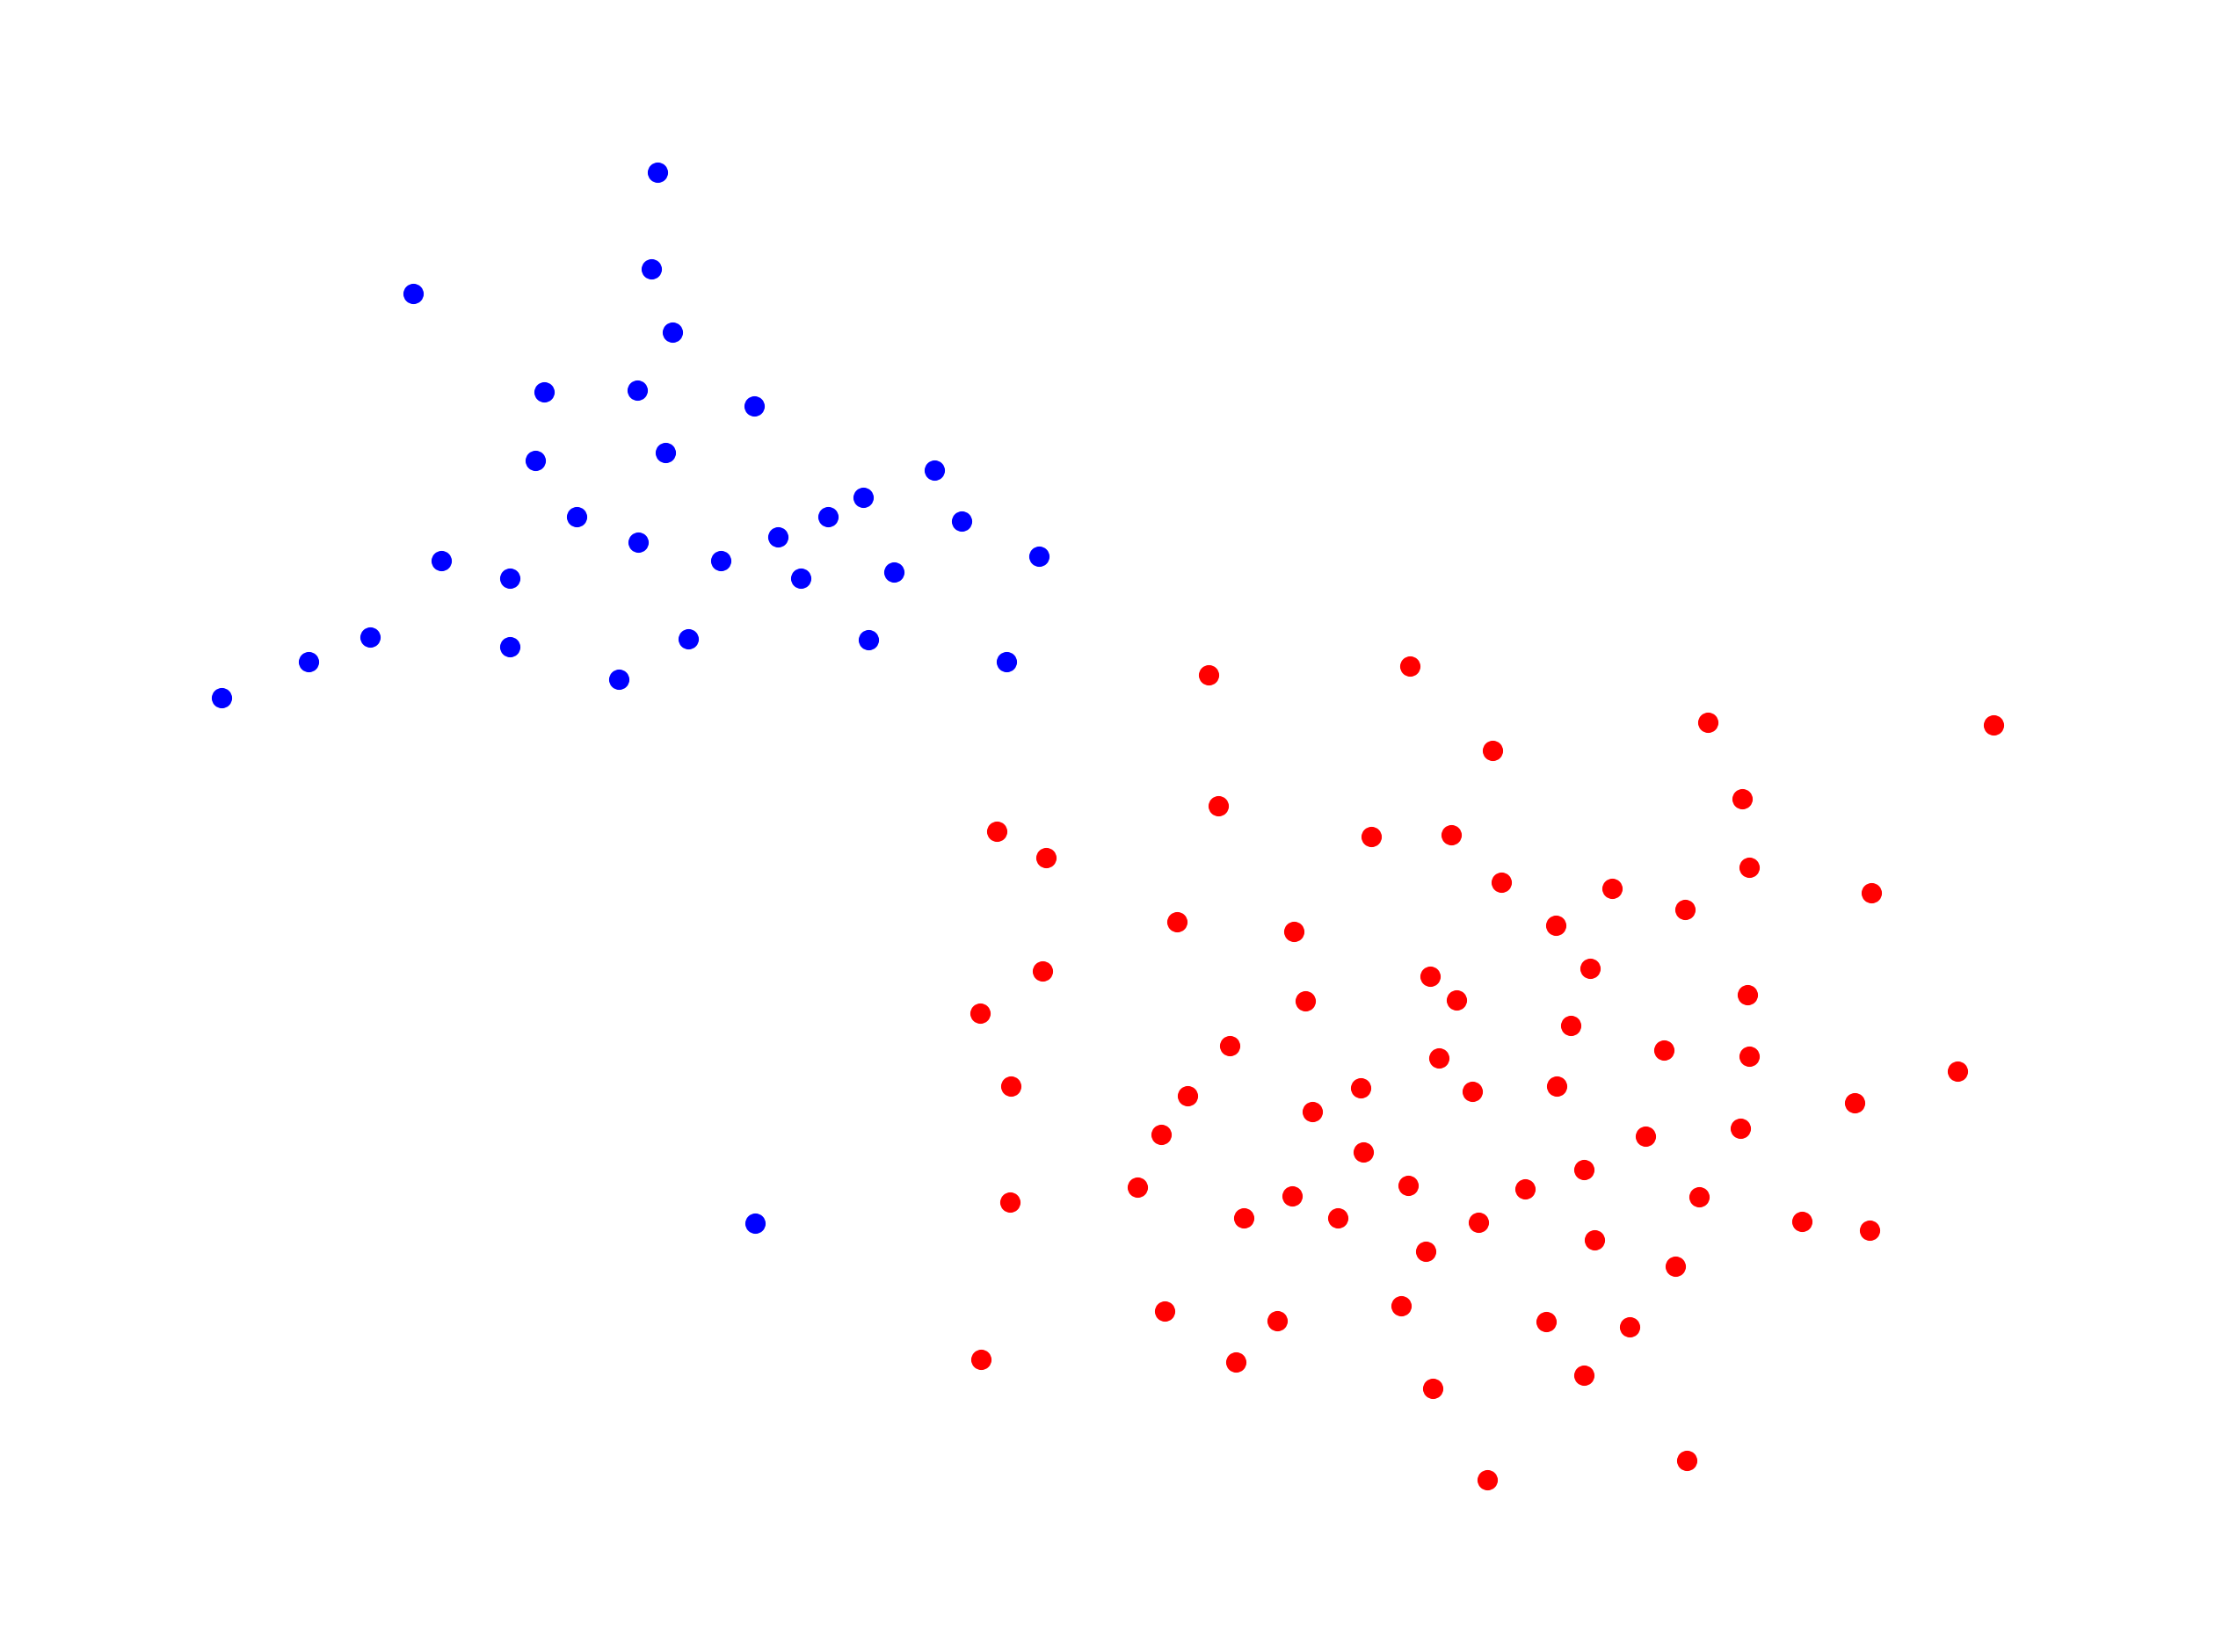

In [169]:
nx.draw_networkx_nodes(G, pos, nodelist=G0, node_color=colors[0], node_size=10, alpha=1)
nx.draw_networkx_nodes(G, pos, nodelist=G1, node_color=colors[1], node_size=10, alpha=1)
nx.draw_networkx_edges(G, pos, edgelist=E0, width=W0, edge_color=colors[0], alpha=0)
nx.draw_networkx_edges(G, pos, edgelist=E1, width=W1, edge_color=colors[1], alpha=0)
nx.draw_networkx_edges(G, pos, edgelist=E01, width=W01, edge_color="seagreen", alpha=0)

plt.tight_layout()
plt.axis('off')
plt.gcf().set_dpi(400)
plt.show()

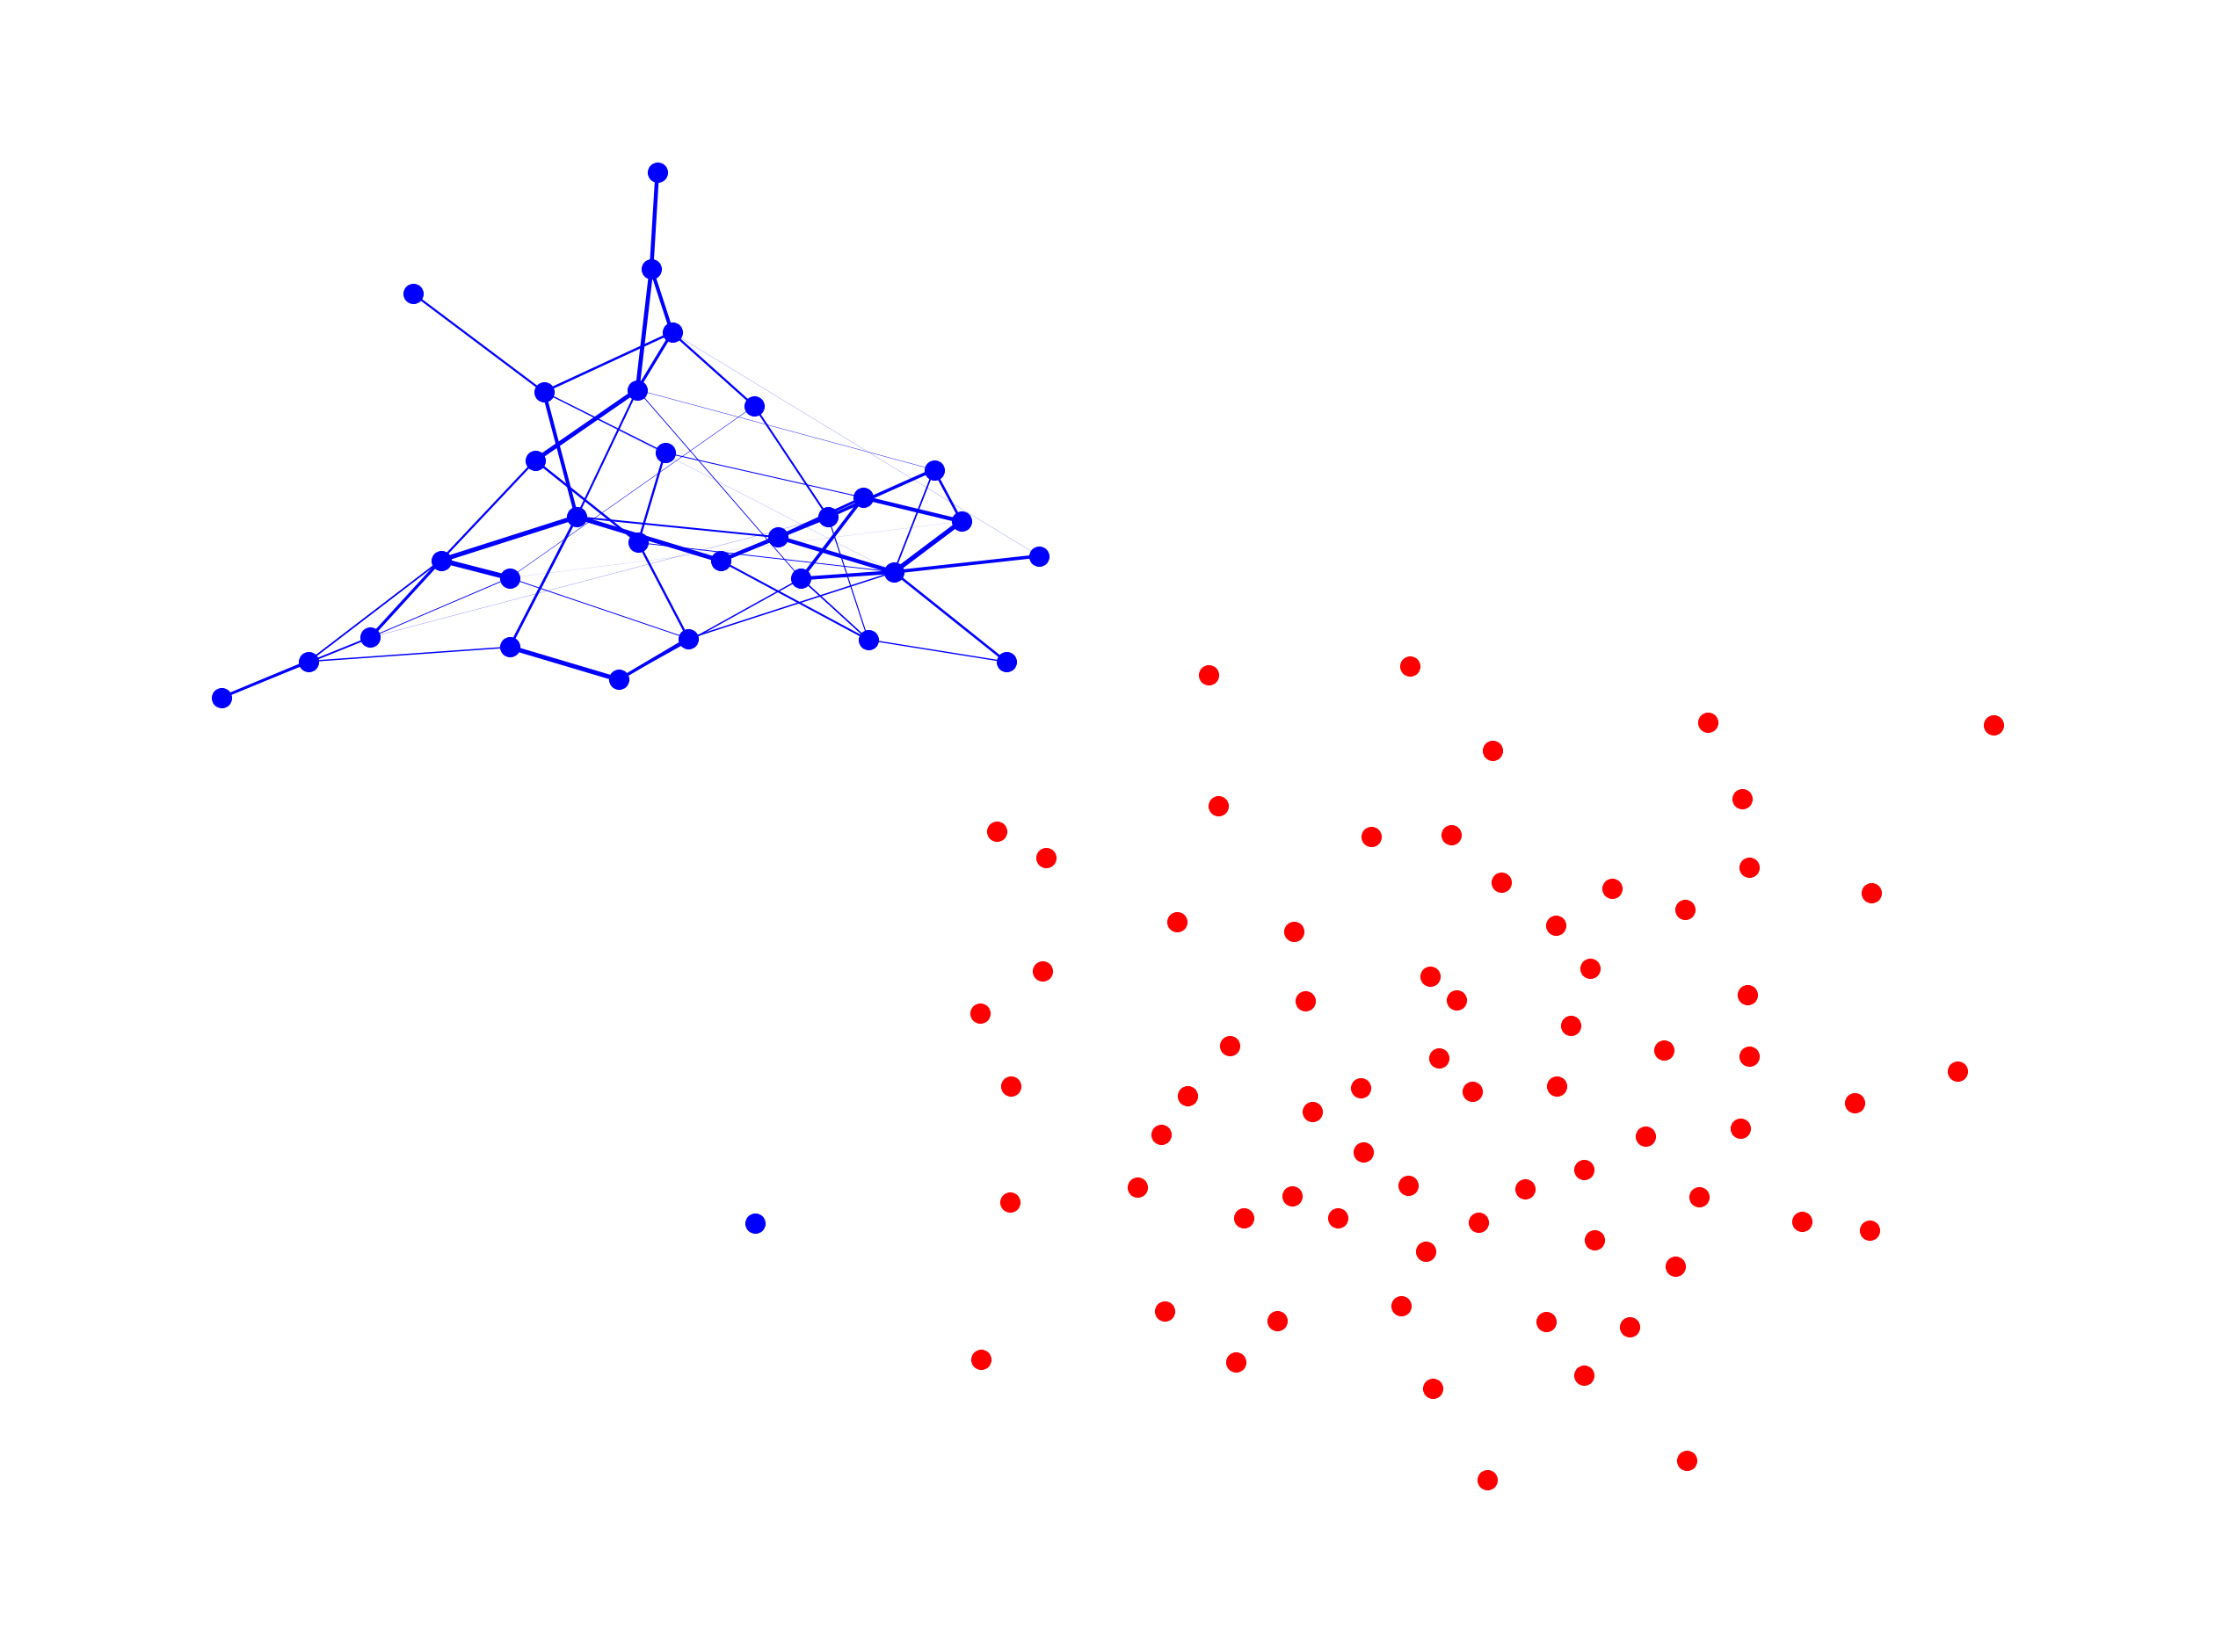

In [ ]:
nx.draw_networkx_nodes(G, pos, nodelist=G0, node_color=colors[0], node_size=10, alpha=1)
nx.draw_networkx_nodes(G, pos, nodelist=G1, node_color=colors[1], node_size=10, alpha=1)
nx.draw_networkx_edges(G, pos, edgelist=E0, width=W0, edge_color=colors[0], alpha=1)
nx.draw_networkx_edges(G, pos, edgelist=E1, width=W1, edge_color=colors[1], alpha=0)
nx.draw_networkx_edges(G, pos, edgelist=E01, width=W01, edge_color="seagreen", alpha=0)

plt.tight_layout()
plt.axis('off')
plt.gcf().set_dpi(400)
plt.show()

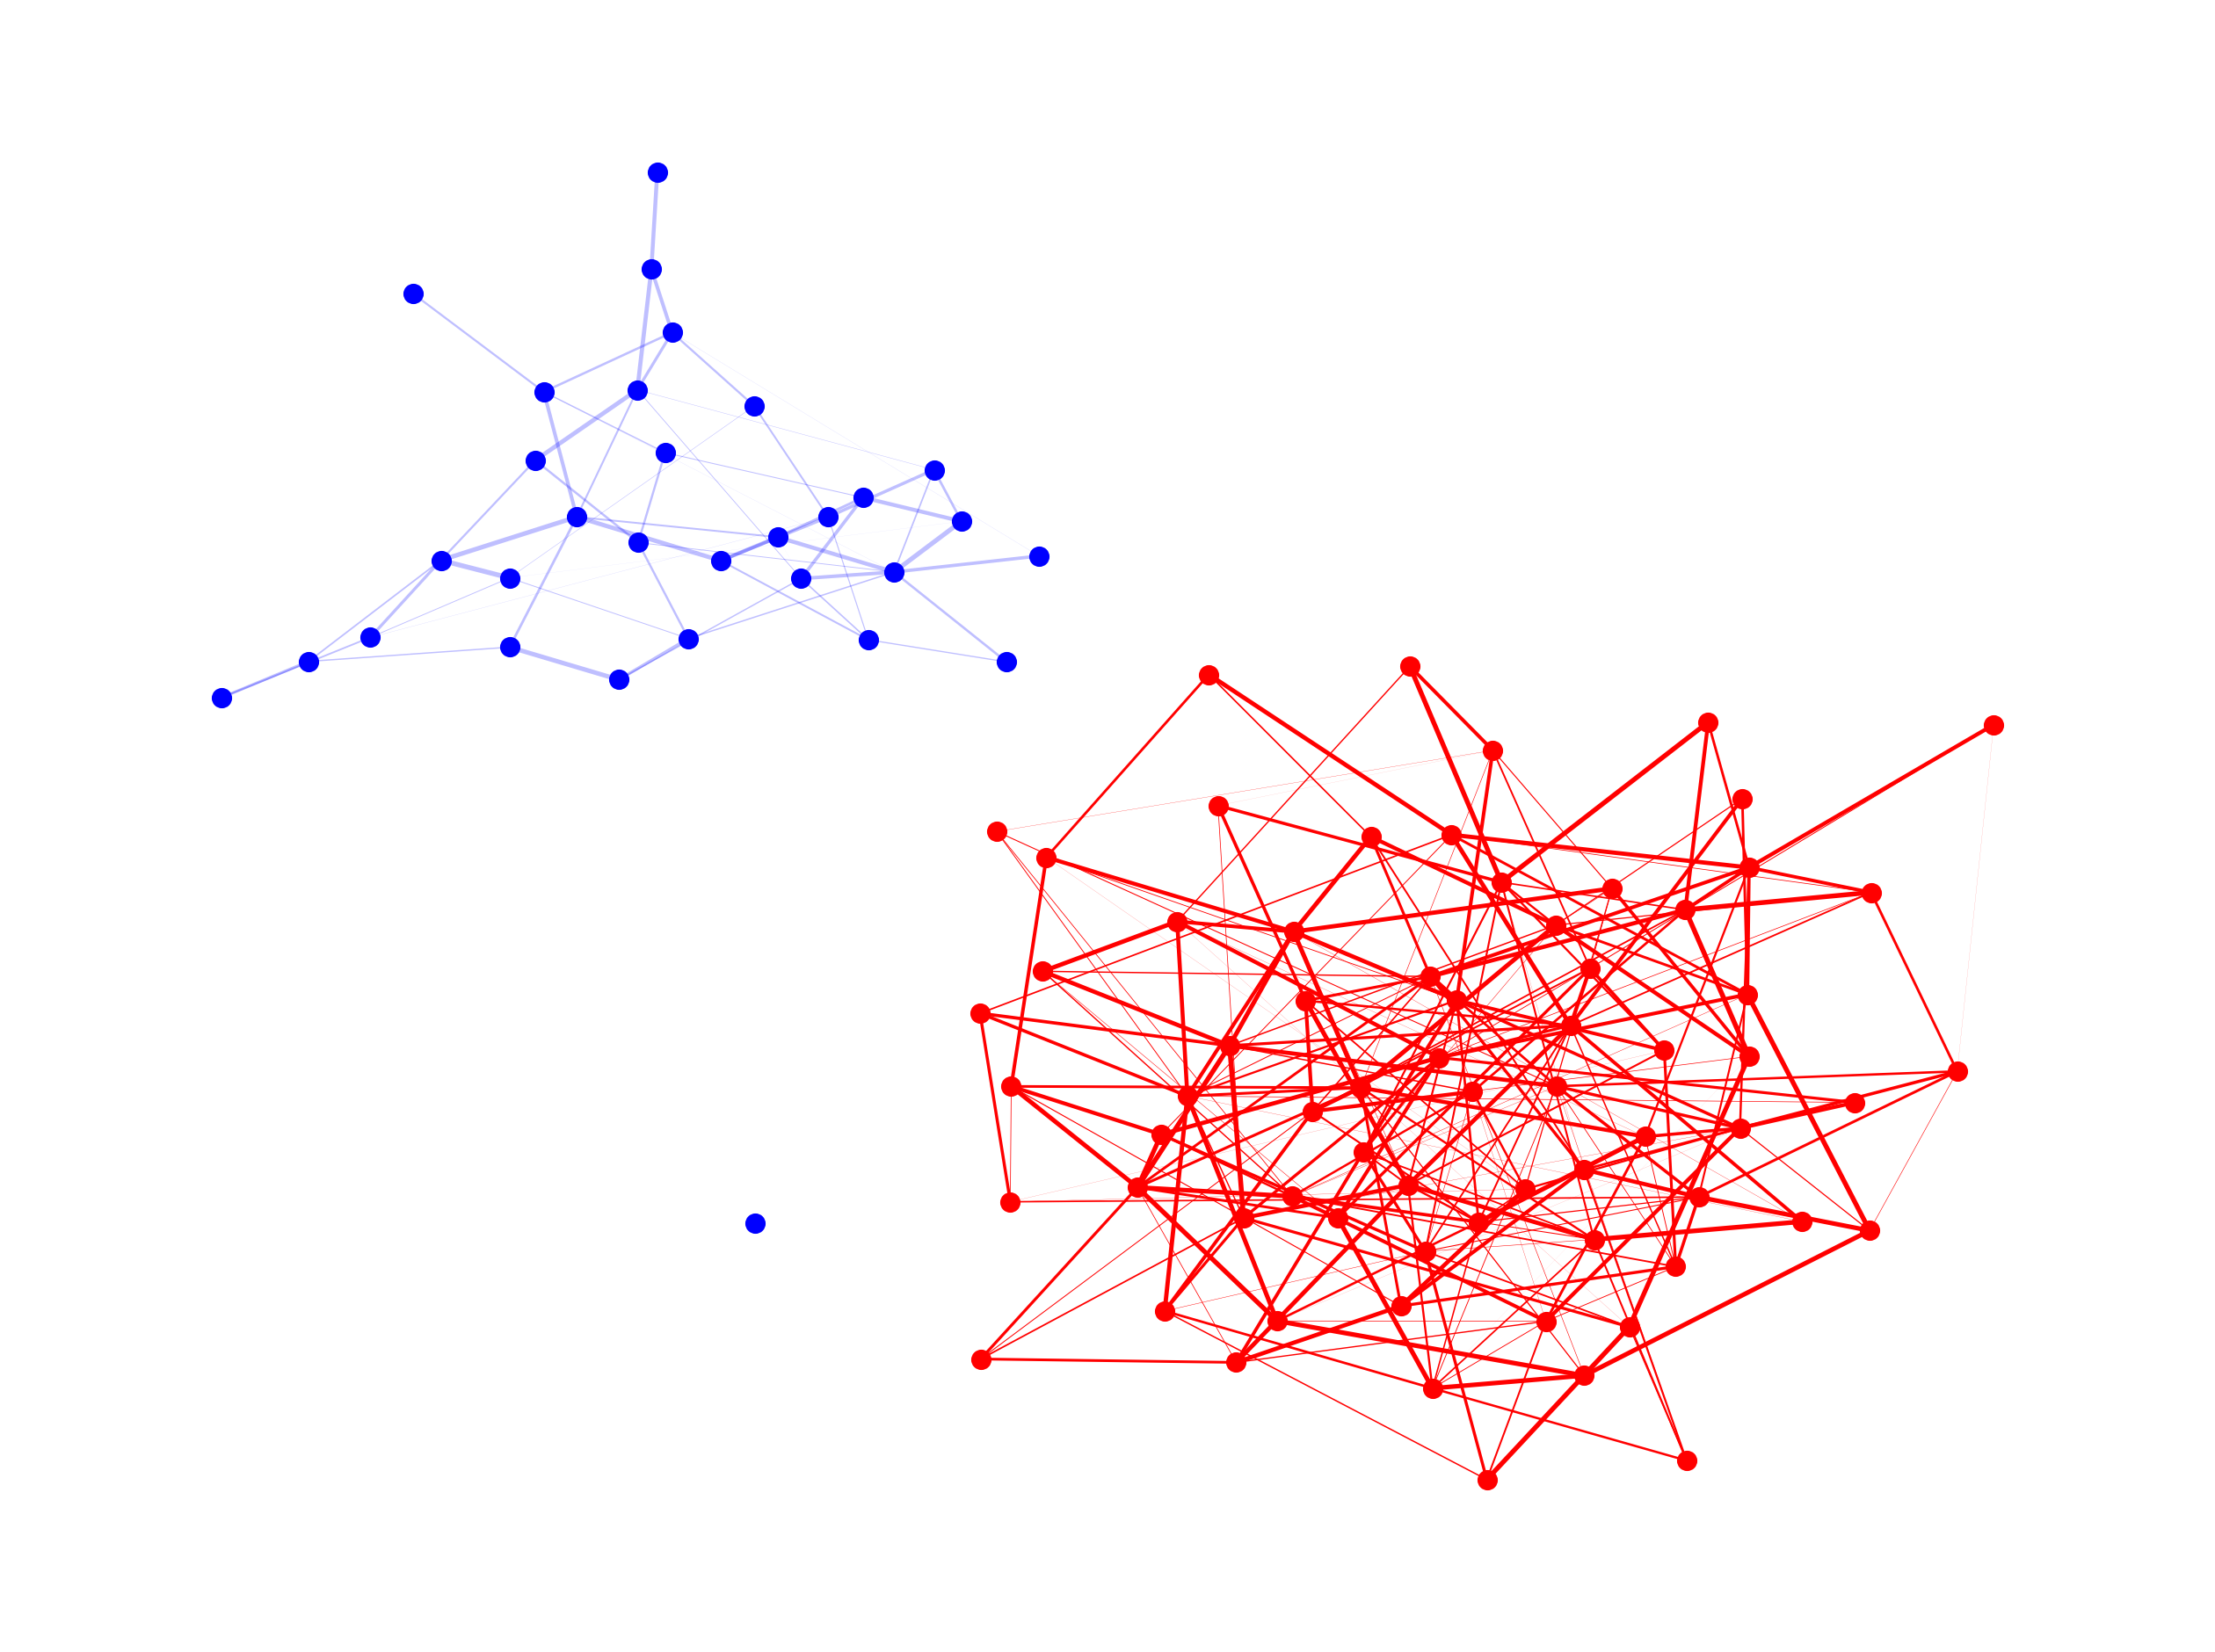

In [173]:
nx.draw_networkx_nodes(G, pos, nodelist=G0, node_color=colors[0], node_size=10, alpha=1)
nx.draw_networkx_nodes(G, pos, nodelist=G1, node_color=colors[1], node_size=10, alpha=1)
nx.draw_networkx_edges(G, pos, edgelist=E0, width=W0, edge_color=colors[0], alpha=0.25)
nx.draw_networkx_edges(G, pos, edgelist=E1, width=W1, edge_color=colors[1], alpha=1)
nx.draw_networkx_edges(G, pos, edgelist=E01, width=W01, edge_color="seagreen", alpha=0)

plt.tight_layout()
plt.axis('off')
plt.gcf().set_dpi(400)
plt.show()

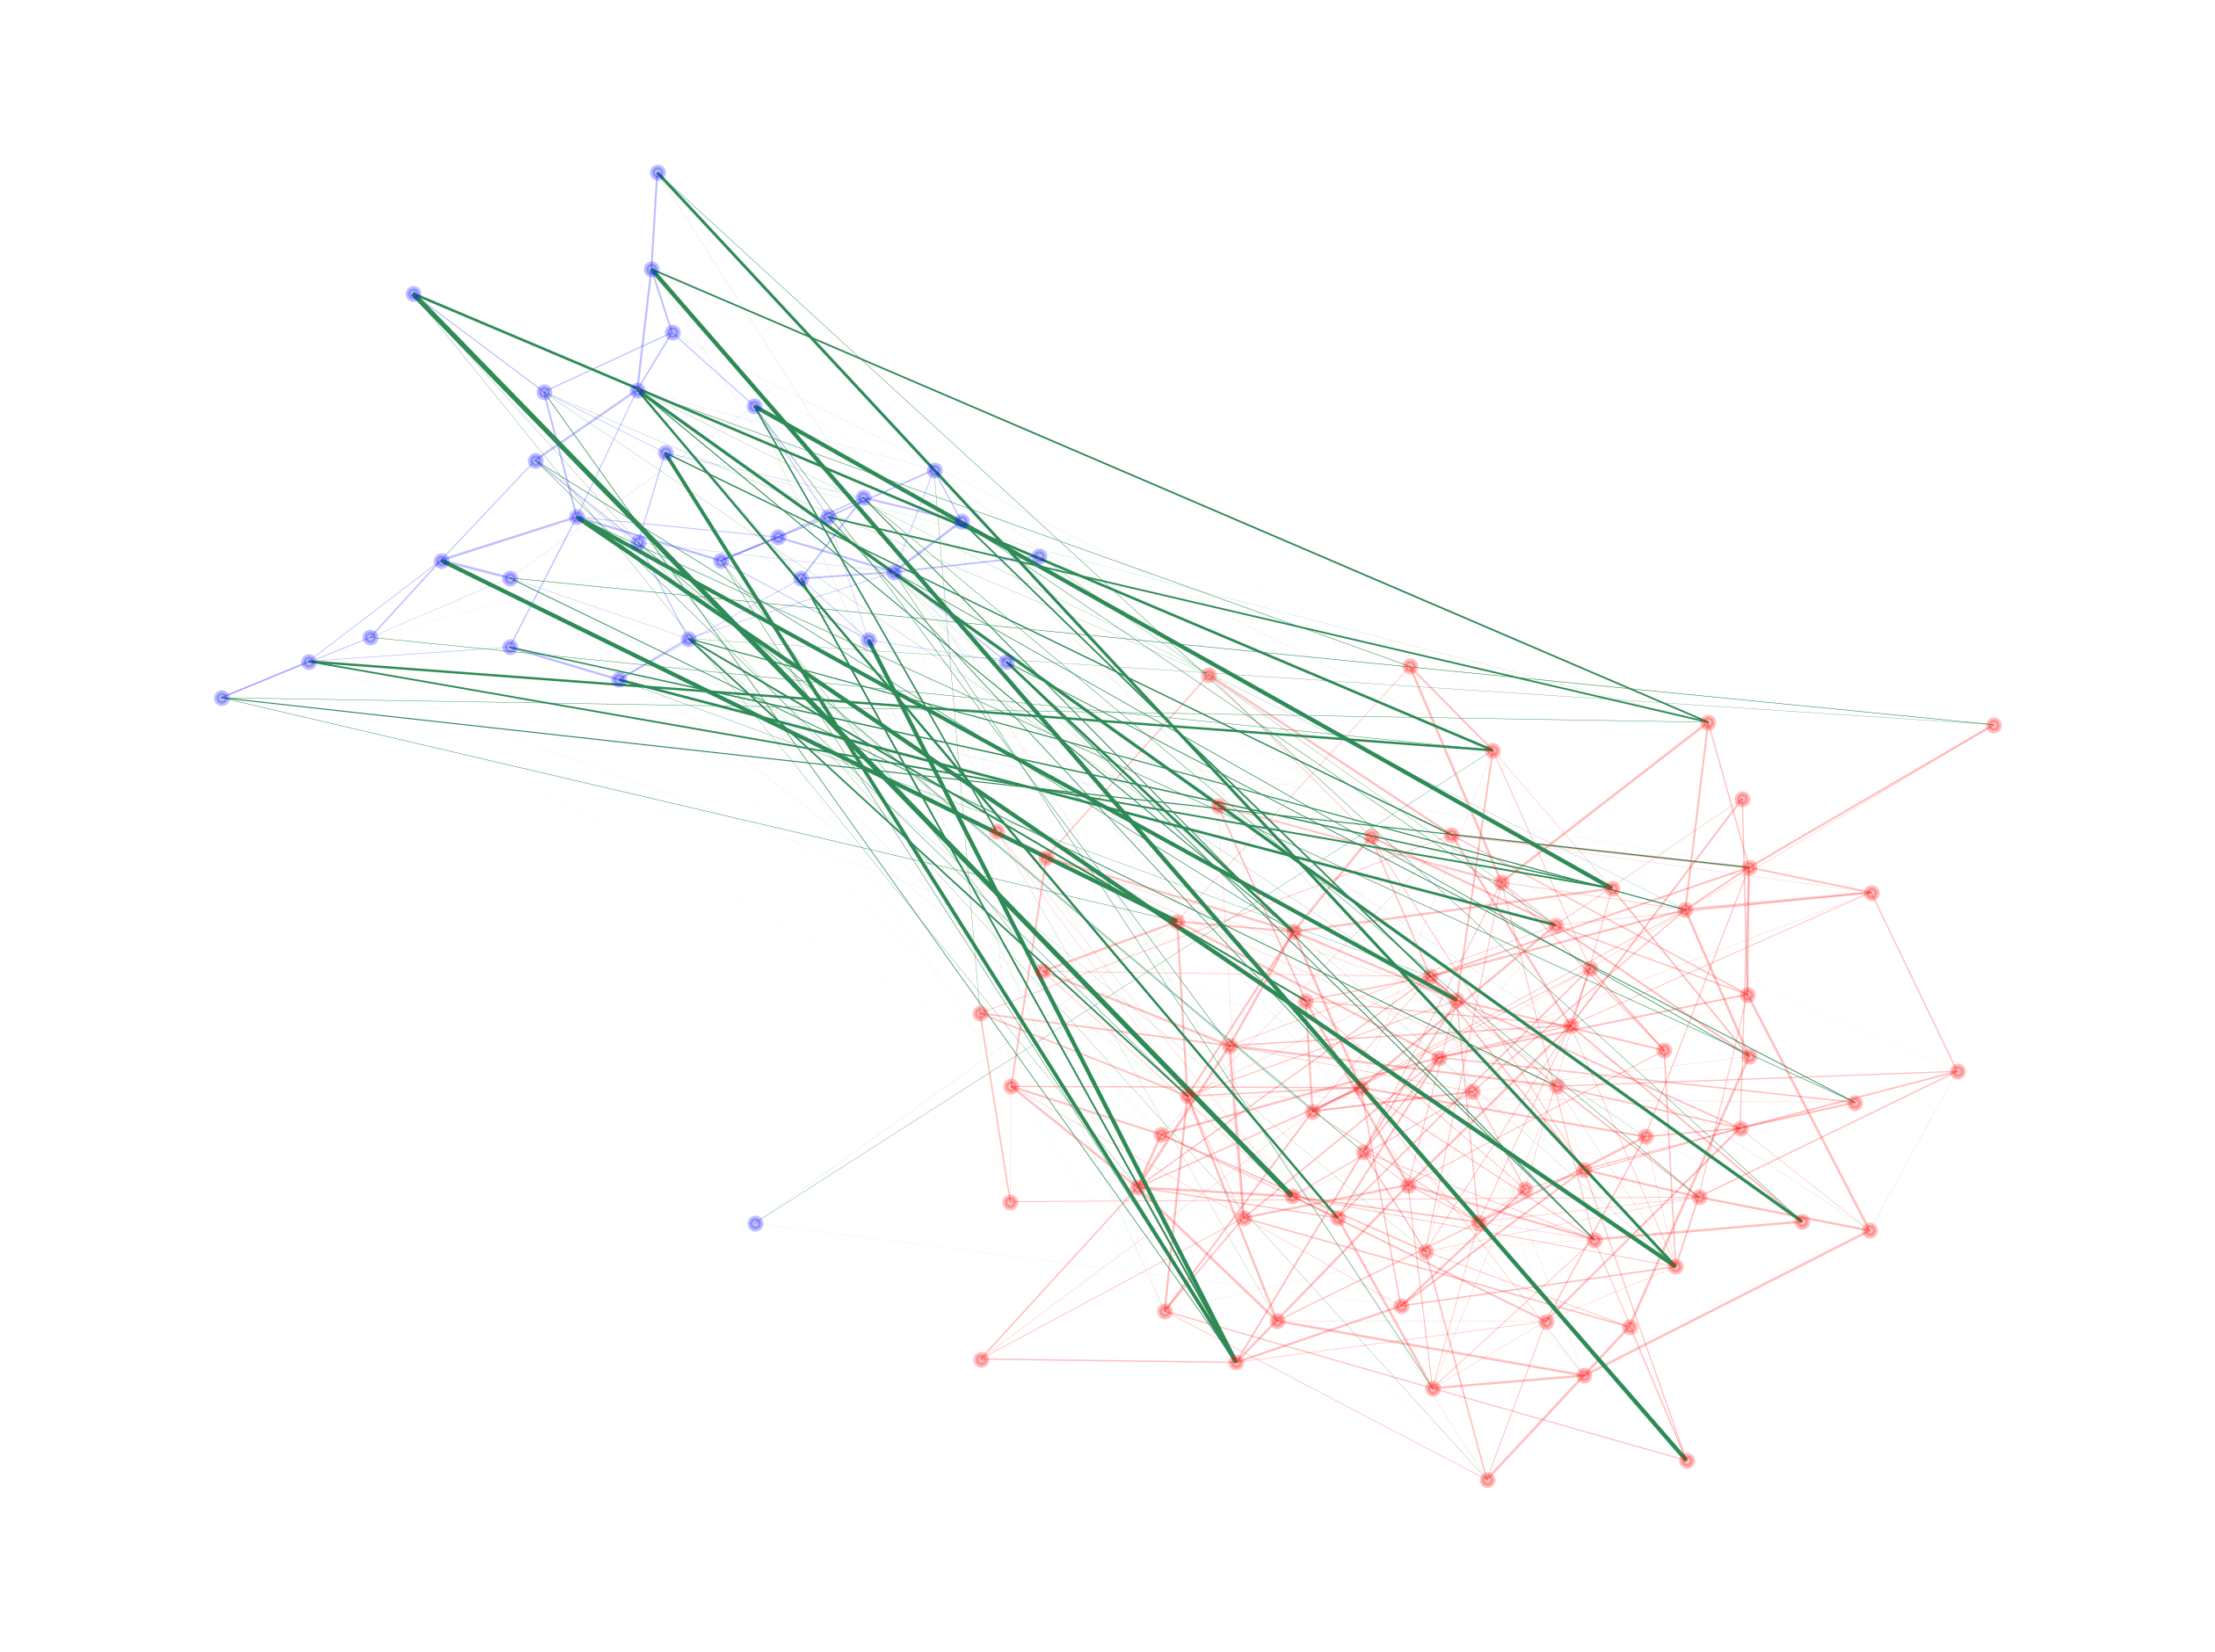

In [178]:
nx.draw_networkx_nodes(G, pos, nodelist=G0, node_color=colors[0], node_size=5, alpha=0.25)
nx.draw_networkx_nodes(G, pos, nodelist=G1, node_color=colors[1], node_size=5, alpha=0.25)
nx.draw_networkx_edges(G, pos, edgelist=E0, width=0.5*W0, edge_color=colors[0], alpha=0.25)
nx.draw_networkx_edges(G, pos, edgelist=E1, width=0.5*W1, edge_color=colors[1], alpha=0.25)
nx.draw_networkx_edges(G, pos, edgelist=E01, width=W01, edge_color="seagreen", alpha=1)

plt.tight_layout()
plt.axis('off')
plt.gcf().set_dpi(400)
plt.show()

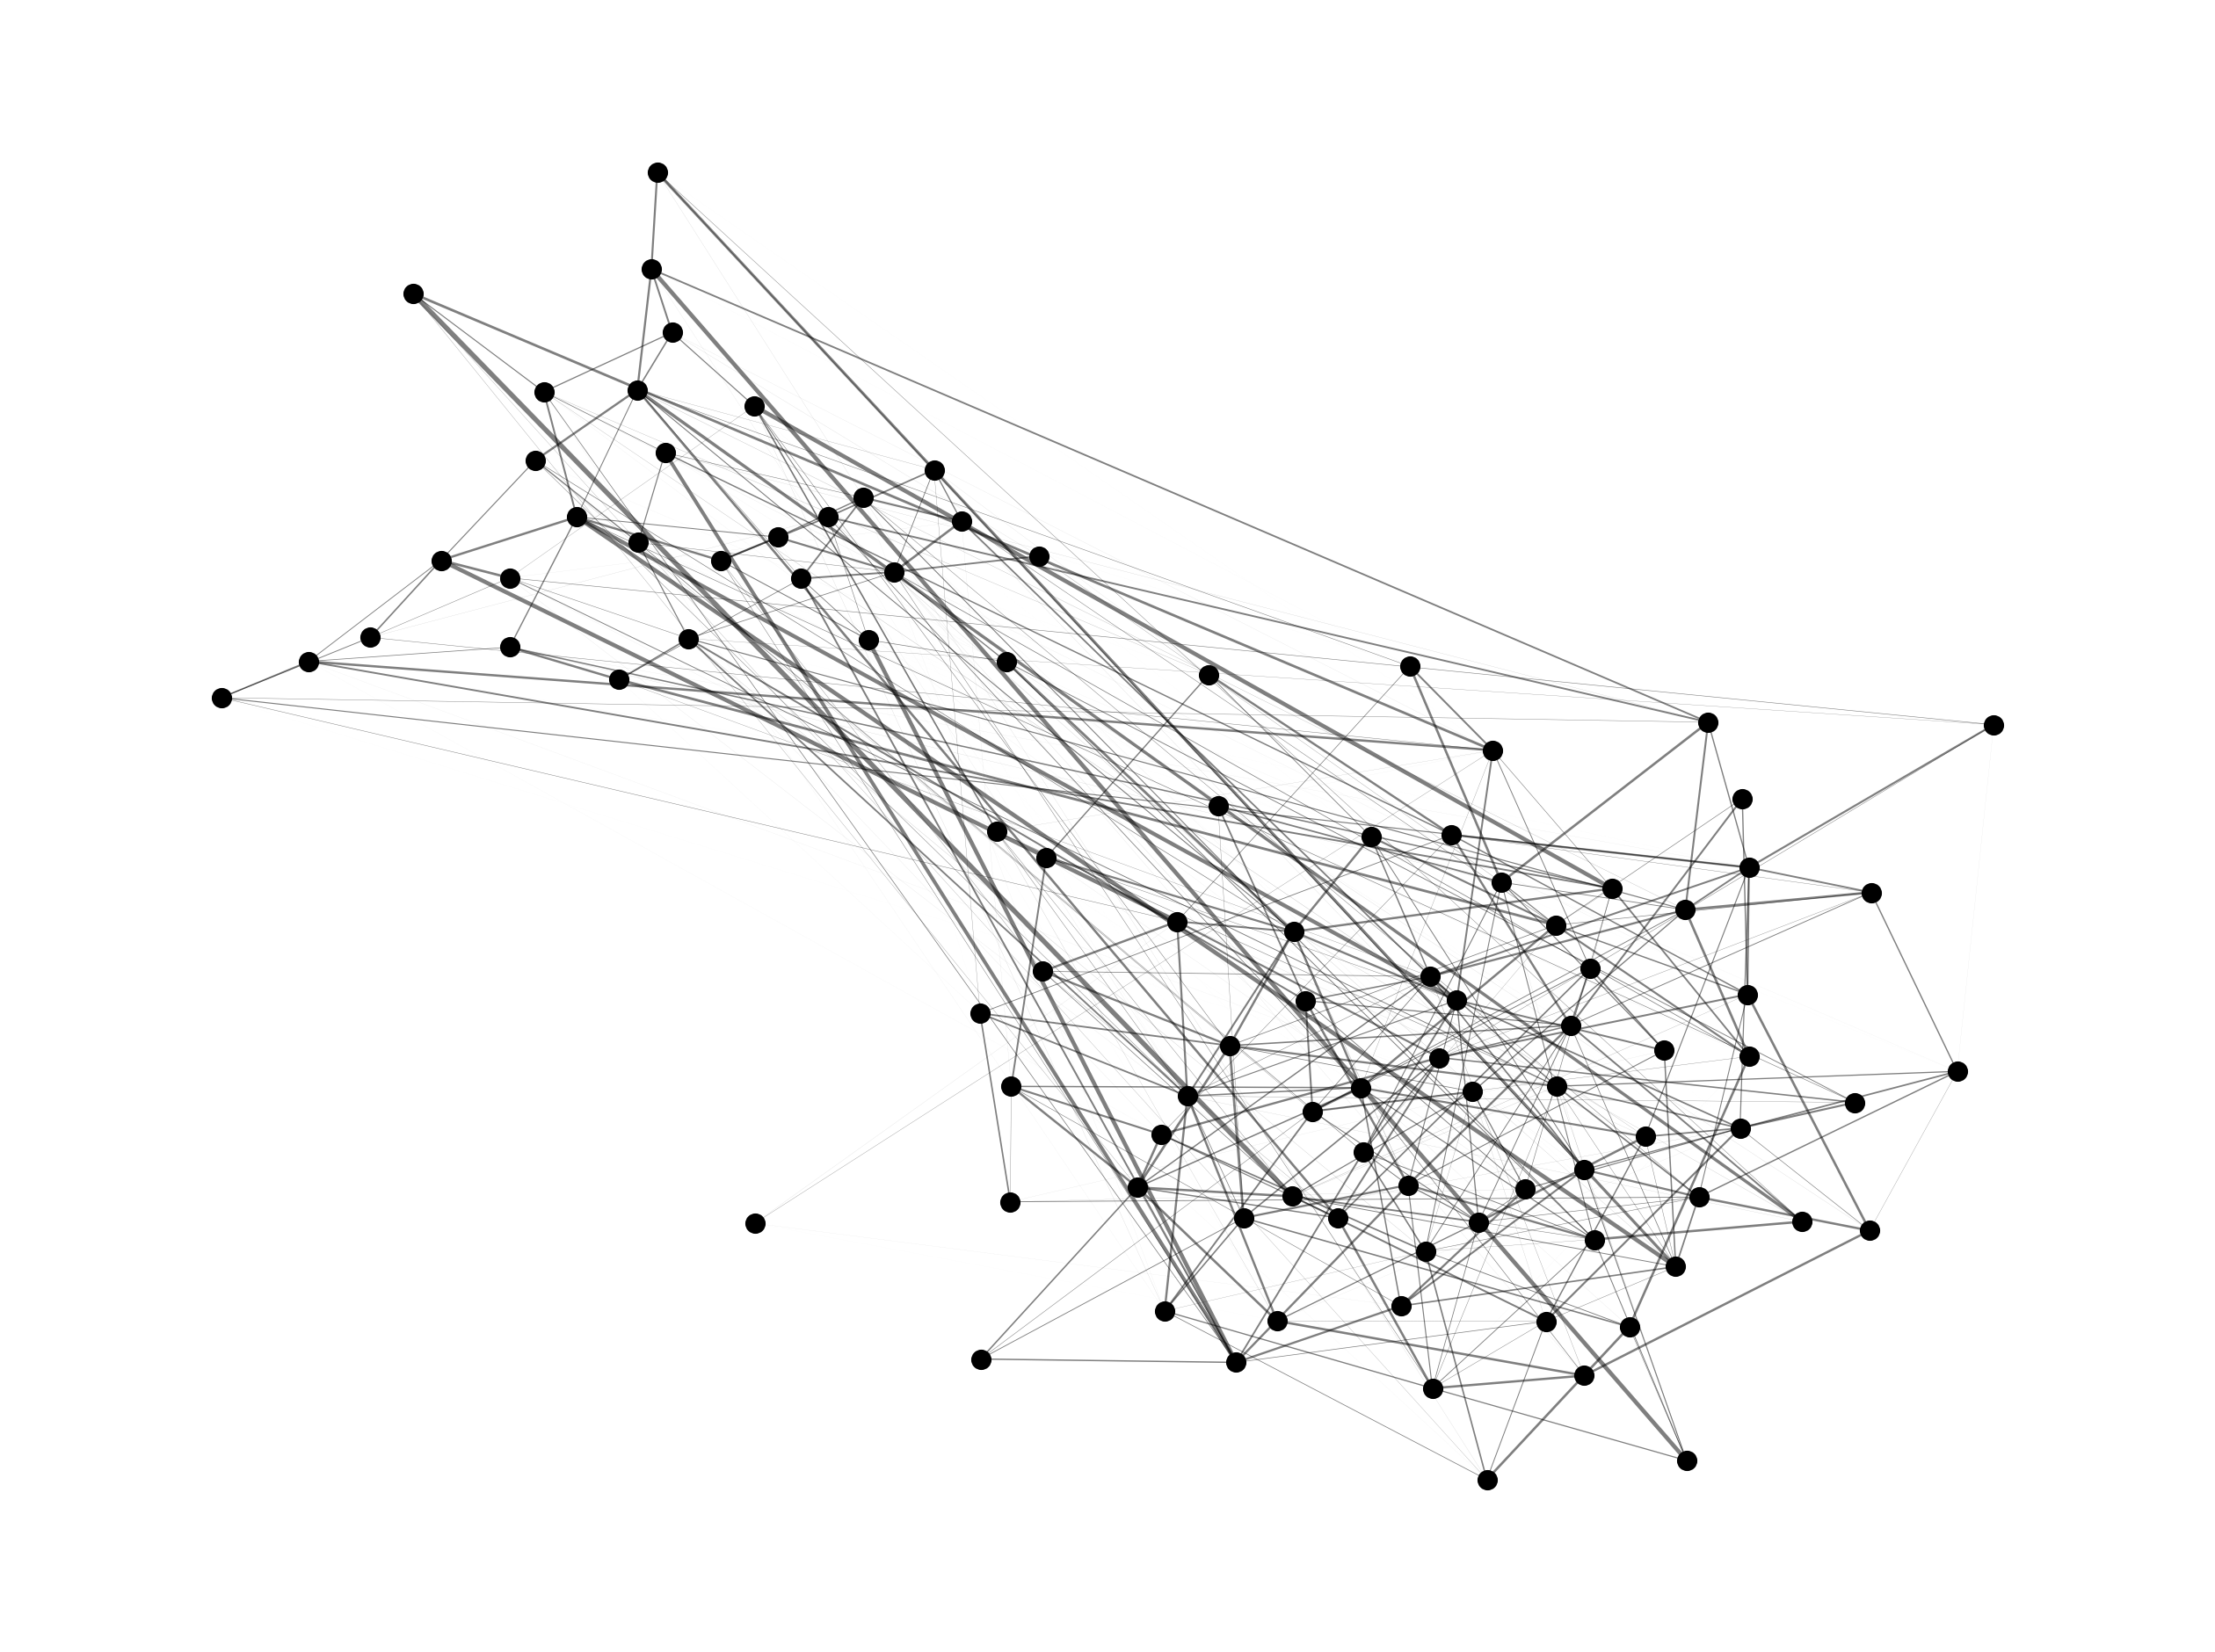

In [181]:
nx.draw_networkx_nodes(G, pos, nodelist=G0, node_color="black", node_size=10, alpha=1)
nx.draw_networkx_nodes(G, pos, nodelist=G1, node_color="black", node_size=10, alpha=1)
nx.draw_networkx_edges(G, pos, edgelist=E0, width=0.5*W0, edge_color="black", alpha=0.5)
nx.draw_networkx_edges(G, pos, edgelist=E1, width=0.5*W1, edge_color="black", alpha=0.5)
nx.draw_networkx_edges(G, pos, edgelist=E01, width=W01, edge_color="black", alpha=0.5)

plt.tight_layout()
plt.axis('off')
plt.gcf().set_dpi(400)
plt.show()